# EDA

In [1]:
# EDA methodology adapted from
# https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Lucky number
random_state = 8

In [3]:
# Loading dataset
dataset = pd.read_csv('../../../data/processed/cs199_data.csv')
dataset.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0


In [4]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

In [5]:
dataset_sorted.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,1171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,1398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Setting attributes
dataset_cleaned = dataset_sorted[[
 #'SAMPLEID',
 #'6_ANSWERDATE',
 '6_SEX', #"1 Male 2 Female"
 '6_AGE',
 #'6_AGEID',
 #'6_PREFECTURE',
 #'6_AREA',
 '6_MARRIED', #"1 unmarried 2 married"
 '6_CHILD', #"1 no children 2 with children"
 '6_HINCOME',
 '6_PINCOME', #same coding as HINCOME
 '6_JOB',
 #'6_STUDENT',
 '6_Number_fam', #Please indicate by number how many people (not including yourself) live with you.
 #'6_SchoolGrade',
 #'6_YearsEnrolled',
 '6_VacNum', #Number of vaccinations

 '6_Med_self', # "I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.) 1 yes 2 no"
 '6_Medself_covid', # "As a medical worker, I am dealing with new corona patients. 1 yes 2 no"
 '6_Med_fam', #"Have a family member who is a healthcare worker 1 yes 2 no"
 '6_Medfam_covid', #"There is a person in the family who is dealing with new corona patients as a medical worker. 　1 yes 2 no"
 '6_Current_physical', #Whether the respondent has been treated for a physical illness in the past
 '6_Past_physical', #Whether the respondent is currently being treated for a mental disorder
 '6_Current_mental', #Whether the respondent has been treated for mental illness in the past
 '6_Past_mental', #Currently being treated for COVID-19
 '6_Current_covid19', #"Currently undergoing treatment for COVID-19. 1 yes 2 no"
 '6_Past_covid19', #"Have received treatment for COVID-19 in the past. 1 yes 2 no"

 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',

 '6_PB_Continuous', #We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
 '6_PB_Altruistic', #Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
 '6_PB_Avoidant', #To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',

 #'6_PTG1_S22',
 #'6_PTG2_S23',
 #'6_PTG3_S24',
 #'6_PTG4_S25',
 #'6_PTG5_S_26',
 #'6_PTG6_S27',
 #'6_Social_Capital_Q8S1',
 #'6_Social_Capital_Q8S2',
 #'6_Social_Capital_Q8S3',
 #'6_Social_Capital_Q8S4',
 #'6_Social_Capital_Q8S5',
 #'6_Social_Capital_Q9S1',
 #'6_Social_Capital_Q9S2',
 #'6_Social_Capital_Q9S3',
 #'6_Social_Capital_Q10S1_1',
 #'6_Social_Capital_Q10S1_2',
 #'6_Social_Capital_Q10S1_3',
 #'6_Social_Capital_Q10S1_4',
 #'6_Social_Capital_Q10S1_5',
 #'6_Social_Capital_Q10S1_6',
 #'6_Social_Capital_Q10S1_7',
 #'6_Social_Capital_Q10S1_8',
 #'6_Social_Capital_Q10S2_1',
 #'6_Social_Capital_Q10S2_2',
 #'6_Social_Capital_Q10S2_3',
 #'6_Social_Capital_Q10S2_4',
 #'6_Social_Capital_Q10S2_5',
 #'6_Social_Capital_Q10S2_6',
 #'6_Social_Capital_Q10S2_7',
 #'6_Social_Capital_Q10S2_8',
 #'6_Social_Capital_Q10S3_1',
 #'6_Social_Capital_Q10S3_2',
 #'6_Social_Capital_Q10S3_3',
 #'6_Social_Capital_Q10S3_4',
 #'6_Social_Capital_Q10S3_5',
 #'6_Social_Capital_Q10S3_6',
 #'6_Social_Capital_Q10S3_7',
 #'6_Social_Capital_Q10S3_8',
 #'6_Social_Capital_Q10S1_7FA',
 #'6_Social_Capital_Q10S2_7FA',
 #'6_Social_Capital_Q10S3_7FA',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT']]

 #'6_Age_group',
 #'6_HINCOME_group',
 #'6_JOB_group',
 #'6_Med_group',
 #'6_Med_covid_group',
 #'6_Physical_group',
 #'6_Mental_group',
 #'6_Covid_group',
 #'6_K6_group3',
 #'6_K6_group2',
 #'6_PHQ9_%',
 #'6_GAD_%',
 #'6_PHQ9_item9',
 #'6_PHQ9_SI',
 #'6_LSNS_group',
 #'6_AUDIT_group']

In [7]:
dataset_cleaned

,6_SEX,6_AGE,6_MARRIED,6_CHILD,6_HINCOME,6_PINCOME,6_JOB,6_Number_fam,6_VacNum,6_Med_self,...,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
dataset_cleaned.shape

(24050, 49)

# Preprocessing

In [9]:
# Get initial number of rows
initial_rows = len(dataset_sorted)

# Convert all columns to numeric, forcing non-numeric values to NaN
dataset_cleaned = dataset_cleaned.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values (originally non-numeric values)
dataset_cleaned = dataset_cleaned.dropna()

# Get final number of rows
final_rows = len(dataset_cleaned)
row_count = len(dataset_cleaned)

# Print number of dropped rows
print(f"Number of rows dropped: {initial_rows - final_rows}")


Number of rows dropped: 21391


In [10]:
Q1 = dataset_cleaned[['6_HINCOME', '6_PINCOME']].quantile(0.25)
Q3 = dataset_cleaned[['6_HINCOME', '6_PINCOME']].quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers
dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['6_HINCOME', '6_PINCOME']] < (Q1 - 1.5 * IQR)) | 
                                    (dataset_cleaned[['6_HINCOME', '6_PINCOME']] > (Q3 + 1.5 * IQR))).any(axis=1)]

new_rows = len(dataset_cleaned)
print(f"Number of rows dropped: {row_count - new_rows}")
row_count = new_rows


Number of rows dropped: 343


In [11]:
column = '6_SEX'

def sex_categories(x):
    if x == 1:
        return 'Male'
    else:
        return 'Female'


# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(sex_categories)

In [12]:
column = '6_MARRIED'

def married_categories(x):
    if x == 1:
        return 'Unmarried'
    else:
        return 'Married'
    
# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(married_categories)

In [13]:
column = '6_JOB'

def job_categories(x):
    if x == 1:
        return 'Civil Servant'
    elif x == 2:
        return 'Management and Officers'
    elif x == 3:
        return 'Company Employee (Clerical)'
    elif x == 4: 
        return 'Company Employee (Technical)'
    elif x == 5:
        return 'Company Employee (Other)'
    elif x == 6:
        return 'Self-employed'
    elif x == 7:
        return 'Freelance'
    elif x == 8:
        return 'Full-time Housewife/Househusband'
    elif x == 9:
        return 'Part-time Worker'
    elif x == 10:
        return 'Student'
    elif x == 11:
        return 'Others'
    else:
        return 'Unemployed'
    
# Transform columns in categorical descriptions
dataset_cleaned[column] = dataset_cleaned[column].apply(job_categories)

In [14]:
columns = [
 '6_Med_self', # "I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.) 1 yes 2 no"
 '6_Medself_covid', # "As a medical worker, I am dealing with new corona patients. 1 yes 2 no"
 '6_Med_fam', #"Have a family member who is a healthcare worker 1 yes 2 no"
 '6_Medfam_covid', #"There is a person in the family who is dealing with new corona patients as a medical worker. 　1 yes 2 no"
 '6_Current_physical', #Whether the respondent has been treated for a physical illness in the past
 '6_Past_physical', #Whether the respondent is currently being treated for a mental disorder
 '6_Current_mental', #Whether the respondent has been treated for mental illness in the past
 '6_Past_mental', #Currently being treated for COVID-19
 '6_Current_covid19', #"Currently undergoing treatment for COVID-19. 1 yes 2 no"
 '6_Past_covid19' #"Have received treatment for COVID-19 in the past. 1 yes 2 no"
]
 
def yesno_categories(x):
    if x == 1:
        return 'Yes'
    else:
        return 'No'
    
# Transform columns in categorical descriptions
for column in columns:
    dataset_cleaned[column] = dataset_cleaned[column].apply(yesno_categories)

In [15]:
dataset_cleaned

,6_SEX,6_AGE,6_MARRIED,6_CHILD,6_HINCOME,6_PINCOME,6_JOB,6_Number_fam,6_VacNum,6_Med_self,...,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,Male,57.0,Married,2.0,4.0,3.0,Company Employee (Technical),2.0,3.0,No,...,5.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,Female,70.0,Married,2.0,7.0,1.0,Full-time Housewife/Househusband,3.0,3.0,No,...,6.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,Male,52.0,Unmarried,1.0,3.0,3.0,Company Employee (Clerical),1.0,3.0,No,...,1.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,Male,66.0,Married,2.0,4.0,2.0,Company Employee (Clerical),3.0,3.0,No,...,1.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
21,Male,62.0,Unmarried,2.0,3.0,3.0,Company Employee (Technical),1.0,5.0,No,...,4.0,0.0,0.0,0.0,6.0,18.0,3.75,24.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11189,Male,73.0,Married,1.0,6.0,5.0,Management and Officers,1.0,6.0,No,...,4.0,0.0,1.0,0.0,4.0,19.0,5.00,28.0,5.0,22.0
11204,Male,57.0,Married,2.0,2.0,2.0,Company Employee (Clerical),3.0,3.0,No,...,5.0,12.0,4.0,7.0,13.0,18.0,4.00,25.0,6.0,6.0
11209,Female,50.0,Married,1.0,5.0,1.0,Full-time Housewife/Househusband,1.0,5.0,No,...,3.0,13.0,6.0,0.0,5.0,12.0,3.75,26.0,4.0,0.0
11288,Female,33.0,Unmarried,1.0,4.0,4.0,Company Employee (Clerical),0.0,3.0,No,...,1.0,2.0,3.0,2.0,14.0,12.0,4.00,27.0,3.0,0.0


In [16]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for standardization
numerical_features = [
 '6_AGE',
 '6_HINCOME',
 '6_PINCOME', #same coding as HINCOME
 '6_VacNum', #Number of vaccinations
    
 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',

 '6_PB_Continuous', #We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
 '6_PB_Altruistic', #Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
 '6_PB_Avoidant', #To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',

 #'6_PTG1_S22',
 #'6_PTG2_S23',
 #'6_PTG3_S24',
 #'6_PTG4_S25',
 #'6_PTG5_S_26',
 #'6_PTG6_S27',
 #'6_Social_Capital_Q8S1',
 #'6_Social_Capital_Q8S2',
 #'6_Social_Capital_Q8S3',
 #'6_Social_Capital_Q8S4',
 #'6_Social_Capital_Q8S5',
 #'6_Social_Capital_Q9S1',
 #'6_Social_Capital_Q9S2',
 #'6_Social_Capital_Q9S3',
 #'6_Social_Capital_Q10S1_1',
 #'6_Social_Capital_Q10S1_2',
 #'6_Social_Capital_Q10S1_3',
 #'6_Social_Capital_Q10S1_4',
 #'6_Social_Capital_Q10S1_5',
 #'6_Social_Capital_Q10S1_6',
 #'6_Social_Capital_Q10S1_7',
 #'6_Social_Capital_Q10S1_8',
 #'6_Social_Capital_Q10S2_1',
 #'6_Social_Capital_Q10S2_2',
 #'6_Social_Capital_Q10S2_3',
 #'6_Social_Capital_Q10S2_4',
 #'6_Social_Capital_Q10S2_5',
 #'6_Social_Capital_Q10S2_6',
 #'6_Social_Capital_Q10S2_7',
 #'6_Social_Capital_Q10S2_8',
 #'6_Social_Capital_Q10S3_1',
 #'6_Social_Capital_Q10S3_2',
 #'6_Social_Capital_Q10S3_3',
 #'6_Social_Capital_Q10S3_4',
 #'6_Social_Capital_Q10S3_5',
 #'6_Social_Capital_Q10S3_6',
 #'6_Social_Capital_Q10S3_7',
 #'6_Social_Capital_Q10S3_8',
 #'6_Social_Capital_Q10S1_7FA',
 #'6_Social_Capital_Q10S2_7FA',
 #'6_Social_Capital_Q10S3_7FA',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT'
]

scaler = StandardScaler()
dataset_cleaned[numerical_features] = scaler.fit_transform(dataset_cleaned[numerical_features])

In [17]:
categorical_columns = [
    '6_SEX',
    '6_MARRIED',
    '6_CHILD',
    '6_JOB',
    '6_Number_fam',
    '6_Med_self',
    '6_Medself_covid',
    '6_Med_fam',
    '6_Medfam_covid',
    '6_Current_physical',
    '6_Past_physical',
    '6_Current_mental',
    '6_Past_mental',
    '6_Current_covid19',
    '6_Past_covid19'
]

dataset_cleaned = pd.get_dummies(dataset_cleaned, columns=categorical_columns, drop_first=True)

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset_cleaned[numerical_features] = scaler.fit_transform(dataset_cleaned[numerical_features])

In [19]:
dataset_cleaned

,6_AGE,6_HINCOME,6_PINCOME,6_VacNum,6_Exercise,6_HealthyDiet,6_FavoriteActivity,6_Interaction_offline,6_Interaction_online,6_PB_Continuous,...,6_Med_self_Yes,6_Medself_covid_Yes,6_Med_fam_Yes,6_Medfam_covid_Yes,6_Current_physical_Yes,6_Past_physical_Yes,6_Current_mental_Yes,6_Past_mental_Yes,6_Current_covid19_Yes,6_Past_covid19_Yes
4,0.492754,0.444444,0.500000,0.272727,0.666667,0.500000,0.500000,0.500000,0.500000,0.500000,...,False,False,False,False,False,False,False,False,False,False
8,0.681159,0.777778,0.166667,0.272727,0.000000,0.833333,0.500000,0.500000,0.666667,1.000000,...,False,False,False,False,False,False,False,False,False,False
11,0.420290,0.333333,0.500000,0.272727,0.166667,0.333333,0.166667,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
15,0.623188,0.444444,0.333333,0.272727,0.833333,0.666667,0.500000,0.666667,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
21,0.565217,0.333333,0.500000,0.454545,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11189,0.724638,0.666667,0.833333,0.545455,0.333333,0.666667,0.666667,0.500000,0.333333,0.166667,...,False,False,False,False,False,False,False,False,False,False
11204,0.492754,0.222222,0.333333,0.272727,0.666667,0.666667,0.500000,0.500000,0.666667,0.666667,...,False,False,False,False,False,False,False,False,False,False
11209,0.391304,0.555556,0.166667,0.454545,0.333333,0.500000,0.500000,0.333333,0.333333,0.333333,...,False,False,False,False,False,False,False,False,False,True
11288,0.144928,0.444444,0.666667,0.272727,0.666667,0.500000,0.500000,0.666667,0.500000,0.500000,...,False,False,False,False,False,False,False,True,False,False


# Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# Extract the target and features
y = dataset_cleaned['6_UCLA_total']
X = dataset_cleaned.drop(columns=['6_UCLA_total'])

#Get the training and test set from the K6 dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(y_test, return_counts=True)

# Model Training

In [22]:
# https://www.geeksforgeeks.org/random-forest-regression-in-python/
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model.__class__.__name__}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print("-" * 30)
    
    return r2

In [24]:
# Train Random Forest Regressor
regressor = RandomForestRegressor(random_state=random_state)
regressor.fit(X_train, y_train)
evaluate(regressor, X_test, y_test)

RandomForestRegressor:
  MAE: 0.0992
  MSE: 0.0168
  RMSE: 0.1295
  R²: 0.5988
------------------------------


0.5987667405525514

# Model Tuning

In [25]:
import pprint
import joblib as job
import time

from sklearn.model_selection import GridSearchCV

pp = pprint.PrettyPrinter(indent=1)

In [26]:
# Define hyperparameter space
n_estimators = [100]                       # Range of trees
max_features = [10]                  # Feature selection
max_depth = [None]                                 # Depth
min_samples_split = [2]                     # Control overfitting
min_samples_leaf = [1]                       # Prevent overfitting
max_samples = [0.3, 0.5, 0.7, 0.9, 1.0, None]
ccp_alpha = [0.0, 0.01, 0.05, 0.1, 0.2]
warm_start = [True, False]
bootstrap = [True, False]                              # Sampling strategy

cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap,
               'max_samples': max_samples,
               'ccp_alpha': ccp_alpha,
               'warm_start': warm_start
               }

print('Hyperparameter search space')
pp.pprint(random_grid)

Hyperparameter search space
{'bootstrap': [True, False],
 'ccp_alpha': [0.0, 0.01, 0.05, 0.1, 0.2],
 'max_depth': [None],
 'max_features': [10],
 'max_samples': [0.3, 0.5, 0.7, 0.9, 1.0, None],
 'min_samples_leaf': [1],
 'min_samples_split': [2],
 'n_estimators': [100],
 'warm_start': [True, False]}


In [27]:
# Set model to RandomForestRegressor
model = RandomForestRegressor(random_state=random_state)

In [28]:
start_time = time.time()
grid_tuner = GridSearchCV(estimator=model, param_grid=random_grid, cv=cv, scoring='r2', 
                     verbose=6, return_train_score=True, n_jobs=10)
print('\nCross-validation via', grid_tuner)

# Fit the random search model
print("Fitting the Grid Search model...")
grid_tuner.fit(X_train, y_train)
print("Grid Search CV completed.")

end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')


Cross-validation via GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=8), n_jobs=10,
             param_grid={'bootstrap': [True, False],
                         'ccp_alpha': [0.0, 0.01, 0.05, 0.1, 0.2],
                         'max_depth': [None], 'max_features': [10],
                         'max_samples': [0.3, 0.5, 0.7, 0.9, 1.0, None],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [100], 'warm_start': [True, False]},
             return_train_score=True, scoring='r2', verbose=6)
Fitting the Grid Search model...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Grid Search CV completed.

Random Forest training time: 54.26009154319763 s


In [29]:
# Save the model
model_name = type(grid_tuner).__name__
file_name = model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(grid_tuner, file_save) 

Saving GridSearchCV model as GridSearchCV_20250305-155027.mod ...


['GridSearchCV_20250305-155027.mod']

In [30]:
# Load the model
file_model = "models/GridSearchCV_20250305-155027.mod"
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

Best hyperparameters:
{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 10,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 8,
 'verbose': 0,
 'warm_start': True}


{'n_estimators': [100], 'max_features': [10], 'max_depth': [None], 'min_samples_split': [2], 'min_samples_leaf': [1], 'bootstrap': [True, False], 'max_samples': [0.3, 0.5, 0.7, 0.9, 1.0, None], 'ccp_alpha': [0.0, 0.01, 0.05, 0.1, 0.2], 'warm_start': [True, False]}
n_estimators = 100 : nan
max_features = 10 : nan
max_depth = None : nan
min_samples_split = 2 : nan
min_samples_leaf = 1 : nan
bootstrap = True : 0.1242840581840474
bootstrap = False : nan
max_samples = 0.3 : nan
max_samples = 0.5 : nan
max_samples = 0.7 : nan
max_samples = 0.9 : nan
max_samples = 1.0 : nan
max_samples = None : 0.12465529884500089
ccp_alpha = 0.0 : nan
ccp_alpha = 0.01 : nan
ccp_alpha = 0.05 : nan
ccp_alpha = 0.1 : nan
ccp_alpha = 0.2 : nan
warm_start = True : nan
warm_start = False : nan
{'bootstrap=False_means_test': np.float64(nan),
 'bootstrap=False_means_train': np.float64(nan),
 'bootstrap=False_stds_test': np.float64(nan),
 'bootstrap=False_stds_train': np.float64(nan),
 'bootstrap=True_means_test': np

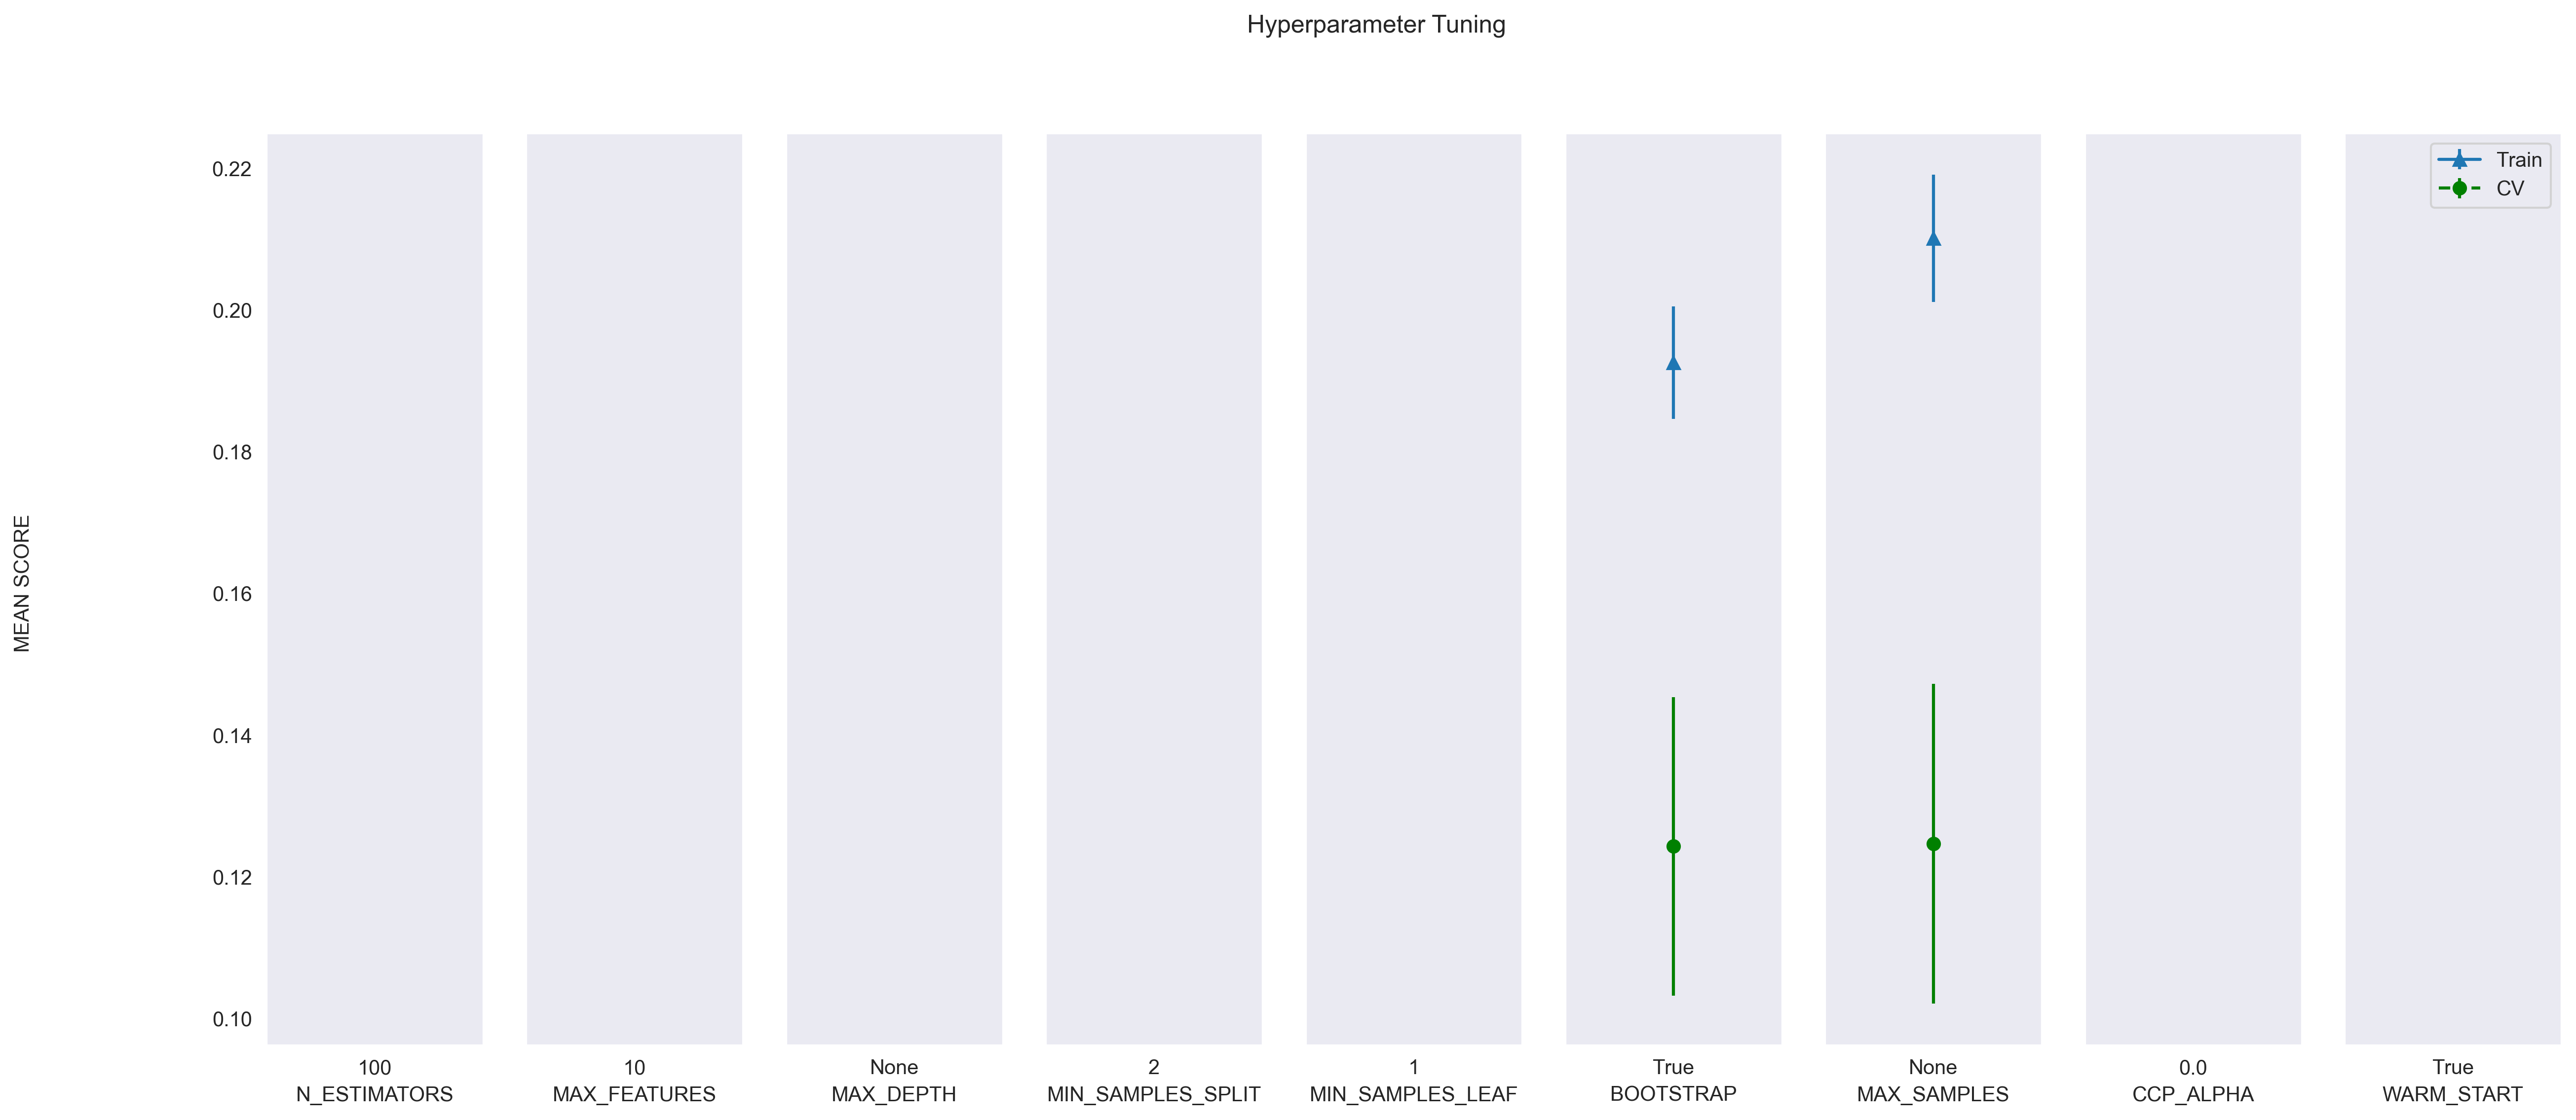

{'mean_fit_time': array([0.25734549, 0.25087972, 0.37984953, 0.36794488, 0.41239996,
       0.41591327, 0.48157718, 0.5044348 , 0.50555711, 0.59260364,
       0.68013434, 0.62999558, 0.40694399, 0.36274328, 0.50565996,
       0.44616139, 0.58902814, 0.57880666, 0.62921586, 0.61932216,
       0.65627818, 0.70105569, 0.6701612 , 0.70466571, 0.33414783,
       0.32459471, 0.45796278, 0.44923713, 0.5858531 , 0.56077504,
       0.68784368, 0.6847425 , 0.67752666, 0.68785312, 0.65846624,
       0.65468614, 0.31020906, 0.33900023, 0.44859483, 0.48319509,
       0.55877619, 0.52730696, 0.61346655, 0.60990422, 0.67976873,
       0.65328517, 0.65534539, 0.7310432 , 0.32932653, 0.33893225,
       0.43330038, 0.44419389, 0.56447725, 0.52750082, 0.61700141,
       0.60743921, 0.67573018, 0.70978146, 0.75535967, 0.79924908,
       0.00678341, 0.00632586, 0.00626597, 0.00749652, 0.00699084,
       0.00682113, 0.00894239, 0.00783107, 0.00779381, 0.00649207,
       0.7137218 , 0.70708594, 0.00626967, 0

In [31]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_grid
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(saved_model)
print(tuner.cv_results_)

In [32]:
## Evaluate model
print('Base model')
base_model = RandomForestRegressor(random_state=random_state)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test, y_test)

print('\nImprovement: {:0.4f}'.format(tuned_accuracy - base_accuracy))

Base model
RandomForestRegressor:
  MAE: 0.0992
  MSE: 0.0168
  RMSE: 0.1295
  R²: 0.5988
------------------------------

Tuned model
RandomForestRegressor:
  MAE: 0.0957
  MSE: 0.0161
  RMSE: 0.1268
  R²: 0.6148
------------------------------

Saved model
RandomForestRegressor:
  MAE: 0.0957
  MSE: 0.0161
  RMSE: 0.1268
  R²: 0.6148
------------------------------

Improvement: 0.0161
